Esta sección del libro aborda uno de los conceptos más críticos al trabajar con árboles de decisión: **la regularización**. Debido a su naturaleza flexible ("no paramétrica"), un árbol sin restricciones intentará memorizar cada ruido y anomalía del conjunto de entrenamiento, destruyendo su capacidad de generalizar con datos nuevos.



A continuación, tienes la traducción adaptada al español técnico, las actualizaciones pertinentes del ecosistema moderno y los scripts para replicar las gráficas de regularización con el dataset *Moons*.

---



## 1. Traducción, Corrección y Actualización del Texto



### Hiperparámetros de Regularización

Los árboles de decisión hacen muy pocas suposiciones sobre los datos de entrenamiento (a diferencia de los modelos lineales, que asumen que los datos siguen una línea recta, por ejemplo). Si no se le imponen restricciones, la estructura del árbol se adaptará por completo a los datos de entrenamiento, ajustándose de forma milimétrica; de hecho, lo más probable es que se produzca un **sobreajuste (overfitting)**.



A este tipo de modelos se les suele llamar **modelos no paramétricos**, no porque carezcan de parámetros (a menudo tienen muchísimos), sino porque el número de parámetros no se determina antes del entrenamiento. Por ello, la estructura del modelo es libre de amoldarse estrechamente a los datos. En contraste, un **modelo paramétrico**, como un modelo lineal, tiene un número predeterminado de parámetros, por lo que sus grados de libertad están limitados, reduciendo el riesgo de sobreajuste (aunque aumentando el riesgo de subajuste o *underfitting*).



Para evitar el sobreajuste con los datos de entrenamiento, es necesario restringir la libertad del árbol de decisión durante su construcción. 

Como ya sabes, esto se conoce como **regularización**. Los hiperparámetros de regularización dependen del algoritmo utilizado, pero por lo general, siempre puedes restringir al menos la profundidad máxima del árbol. 

En Scikit-Learn, esto se controla mediante el hiperparámetro `max_depth`. Su valor por defecto es `None`, lo que significa que no tiene límites. Reducir `max_depth` regularizará el modelo y, por ende, reducirá el riesgo de sobreajuste.



La clase `DecisionTreeClassifier` tiene otros parámetros que restringen de forma similar la forma del árbol:

* **`max_features`**: Número máximo de características que se evalúan para realizar una división en cada nodo.


* **`max_leaf_nodes`**: Número máximo de nodos hoja.
* **`min_samples_split`**: Número mínimo de muestras que debe tener un nodo antes de poder dividirse.
* **`min_samples_leaf`**: Número mínimo de muestras que debe tener un nodo hoja para poder ser creado.
* **`min_weight_fraction_leaf`**: Igual que `min_samples_leaf`, pero expresado como una fracción del número total de instancias ponderadas.
* **`min_impurity_decrease`**: Un nodo se dividirá solo si dicha división produce una reducción de la impureza mayor o igual a este valor.


* **`ccp_alpha`**: Controla la poda por complejidad de costo mínimo (Minimal Cost-Complexity Pruning / MCCP). Poda los subárboles que no reducen la impureza lo suficiente en comparación con su número de hojas. Un valor de `ccp_alpha` más alto genera más poda, dando como resultado un árbol más pequeño (por defecto es 0, sin poda).



Para limitar la complejidad del modelo y regularizarlo, puedes **aumentar** los hiperparámetros que empiezan por `min_*` o el valor de `ccp_alpha`, o bien **disminuir** los hiperparámetros que empiezan por `max_*`.



Ajustar `max_depth` suele ser un excelente punto de partida por defecto: proporciona una regularización efectiva y mantiene el árbol pequeño y fácil de interpretar. Configurar `min_samples_leaf` también es una gran idea, especialmente para conjuntos de datos pequeños. Por último, `max_features` es ideal cuando se trabaja con datasets de alta dimensionalidad (muchas columnas).



> **Nota teórica:** Otros algoritmos funcionan entrenando primero el árbol de decisión por completo sin restricciones para luego **podar (eliminar)** los nodos innecesarios. Un nodo cuyos hijos son todos nodos hoja se considera innecesario si la mejora de la pureza que aporta no es estadísticamente significativa. Se utilizan pruebas estadísticas estándar, como la prueba $\chi^2$ (chi-cuadrado), para estimar la probabilidad de que la mejora sea puramente resultado del azar (lo que se llama la *hipótesis nula*). Si esta probabilidad, llamada *p-valor*, es mayor que un umbral dado (típicamente el 5%, controlado por un hiperparámetro), el nodo se considera innecesario y sus hijos se eliminan. La poda continúa hasta que se eliminan todos los nodos redundantes.



Probemos la regularización en el dataset **Moons**: este es un conjunto de datos de juguete para clasificación binaria en el que los puntos de datos tienen la forma de dos lunas crecientes entrelazadas (ver Figura 5-3). Puedes generar este dataset utilizando la función `make_moons()`.



Entrenaremos un árbol de decisión sin regularización y otro con `min_samples_leaf=5`. Aquí está el código; la Figura 5-3 muestra las fronteras de decisión de cada árbol:



In [1]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)


,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 


# Figura 5-3. Fronteras de decisión de un árbol sin regularizar (izquierda) y un árbol regularizado (derecha)

El modelo sin regularizar de la izquierda claramente está sufriendo de sobreajuste, y el modelo regularizado de la derecha probablemente generalizará mejor. 

Podemos verificar esto evaluando ambos árboles en un conjunto de prueba generado con una semilla aleatoria diferente:



In [2]:
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2, random_state=43)
tree_clf1.score(X_moons_test, y_moons_test)


0.898

In [3]:
tree_clf2.score(X_moons_test, y_moons_test)



0.92


Efectivamente, el segundo árbol tiene una mejor precisión (*accuracy*) en el conjunto de prueba.

---



## 2. Actualizaciones y Consejos Técnicos

* **Poda moderna con `ccp_alpha`:** En el pasado, Scikit-Learn no soportaba de forma nativa la poda posterior (*post-pruning*), obligando a depender exclusivamente de la detención temprana (*pre-pruning*) mediante `max_depth` o `min_samples_leaf`. La inclusión de `ccp_alpha` (basado en Cost-Complexity Pruning) solucionó esto. Es una herramienta avanzada excelente: dejas que el árbol crezca por completo y luego extraes la versión óptima eliminando ramas débiles.
* **Advertencia de reproducibilidad:** Al evaluar modelos con datasets sintéticos como `make_moons`, es mandatorio fijar el parámetro `random_state` tanto en el dataset como en el modelo, ya que el algoritmo CART selecciona características al azar si hay empates exactos en la reducción de impureza.

---



## 3. Scripts de Python para Ejemplificar y Visualizar

Este script completo genera el conjunto de datos *Moons*, entrena ambos modelos, evalúa sus puntuaciones exactas y dibuja las fronteras de decisión lado a lado (reproduciendo con exactitud la esquiva **Figura 5-3** del libro).


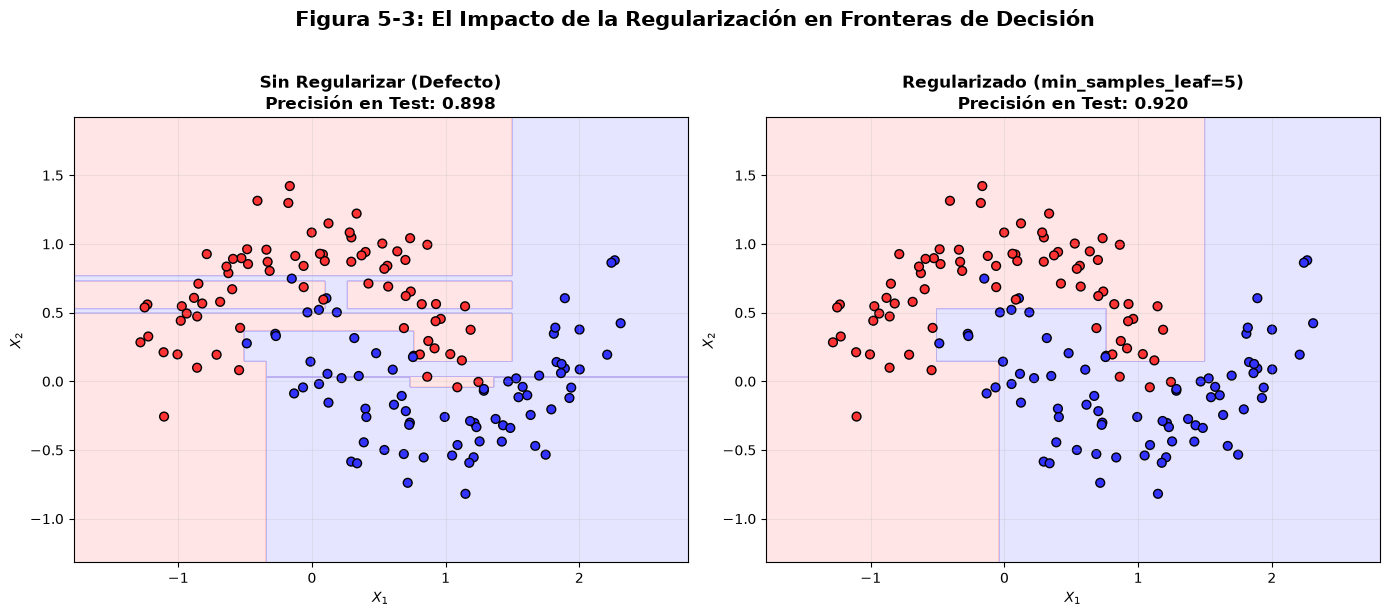

Resultado del modelo sin restricciones: 89.8% de precisión.
Resultado del modelo regularizado:       92.0% de precisión.
-> Se observa claramente cómo el modelo regularizado ignora los islotes de ruido aislados.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

# 1. Generar los conjuntos de datos (Entrenamiento y Prueba)
X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2, random_state=43)

# 2. Entrenar los dos modelos de Árbol de Decisión
tree_clf1 = DecisionTreeClassifier(random_state=42)  # Sin restricciones (Overfitting)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)  # Regularizado

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

# 3. Evaluar el rendimiento en el set de prueba
score1 = tree_clf1.score(X_moons_test, y_moons_test)
score2 = tree_clf2.score(X_moons_test, y_moons_test)

# 4. Función para graficar las fronteras de decisión de forma limpia
def plot_decision_boundary(clf, X, y, ax, title):
    # Configurar los márgenes y crear la malla de píxeles
    x1s = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 500)
    x2s = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 500)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    
    # Predecir las regiones
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    # Mapas de colores suaves para el fondo y fuertes para los puntos
    cmap_back = ListedColormap(['#ffaaaa', '#aaaaff'])
    cmap_points = ListedColormap(['#ff3333', '#3333ff'])
    
    # Dibujar contornos rellenos
    ax.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap_back)
    
    # Graficar los puntos de entrenamiento originales
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points, edgecolor='k', s=40)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("$X_1$", fontsize=10)
    ax.set_ylabel("$X_2$", fontsize=10)
    ax.grid(True, alpha=0.2)

# 5. Crear la figura comparativa lado a lado (Figura 5-3)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subgráfica izquierda: Sin regularización
plot_decision_boundary(tree_clf1, X_moons, y_moons, axes[0], 
                       f"Sin Regularizar (Defecto)\nPrecisión en Test: {score1:.3f}")

# Subgráfica derecha: Con regularización
plot_decision_boundary(tree_clf2, X_moons, y_moons, axes[1], 
                       f"Regularizado (min_samples_leaf=5)\nPrecisión en Test: {score2:.3f}")

plt.suptitle("Figura 5-3: El Impacto de la Regularización en Fronteras de Decisión", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\iris_decision_trees.png", dpi=300)
plt.show()

# Imprimir conclusiones en consola
print(f"Resultado del modelo sin restricciones: {score1 * 100:.1f}% de precisión.")
print(f"Resultado del modelo regularizado:       {score2 * 100:.1f}% de precisión.")
print("-> Se observa claramente cómo el modelo regularizado ignora los islotes de ruido aislados.")



# ¿Qué observar en el resultado visual?

* **En la izquierda (Sin regularización):** Notarás "islas", esquinas extremadamente angostas y ramificaciones artificiales creadas exclusivamente para capturar puntos de un color que quedaron atrapados en la zona del color contrario debido al ruido (`noise=0.2`). Esto es sobreajuste de libro.


* **En la derecha (Regularizado):** Al exigir que cada nodo hoja tenga al menos 5 muestras (`min_samples_leaf=5`), el árbol prefiere ignorar esos puntos aislados de ruido, generando curvas de frontera más suaves y lógicas que se traducen en un rendimiento superior ($92\%$ vs $89.8\%$) ante datos nuevos.